<a href="https://colab.research.google.com/github/lucid005/AI-and-Machine-Learning/blob/main/AIML_Dataset_Overview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Set Dataset Path
DATASET_PATH = '/content/drive/MyDrive/Waste Segregation Classification Dataset'

TRAIN_PATH = os.path.join(DATASET_PATH, 'TRAIN')
TEST_PATH  = os.path.join(DATASET_PATH, 'TEST')

In [4]:
# Explore Folder Structure
print("Folder Structure:")
for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")

Folder Structure:
Waste Segregation Classification Dataset/
  white-glass/
  brown-glass/
  metal/
  plastic/
  green-glass/
  clothes/
  shoes/
  paper/
  cardboard/
  trash/
  battery/
  biological/


In [5]:
def find_image_folders(base_path):
    result = {}
    for root, dirs, files in os.walk(base_path):
        images = [f for f in files if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))]
        if images:
            # Get relative path from base
            rel_path = os.path.relpath(root, base_path)
            result[rel_path] = len(images)
    return result

all_folders = find_image_folders(DATASET_PATH)

print("All folders with images:")
for path, count in all_folders.items():
    print(f"   {path}: {count} images")

All folders with images:
   white-glass: 775 images
   brown-glass: 607 images
   metal: 769 images
   plastic: 865 images
   green-glass: 629 images
   clothes: 5325 images
   shoes: 1977 images
   paper: 1050 images
   cardboard: 891 images
   trash: 697 images
   battery: 945 images
   biological: 985 images


In [6]:
class_totals = {}
category_counts = {}

for rel_path, count in all_folders.items():
    parts = rel_path.replace('\\', '/').split('/')
    # Top level class is always first part
    top_class = parts[0]
    sub_name  = parts[-1]  # deepest folder name

    if top_class not in class_totals:
        class_totals[top_class] = 0
    class_totals[top_class] += count
    category_counts[f"{top_class}/{sub_name}"] = count

print("\nTotal Per Main Class:")
for k, v in class_totals.items():
    print(f"   {k}: {v} images")
print(f"\nGrand Total: {sum(class_totals.values())} images")


Total Per Main Class:
   white-glass: 775 images
   brown-glass: 607 images
   metal: 769 images
   plastic: 865 images
   green-glass: 629 images
   clothes: 5325 images
   shoes: 1977 images
   paper: 1050 images
   cardboard: 891 images
   trash: 697 images
   battery: 945 images
   biological: 985 images

Grand Total: 15515 images


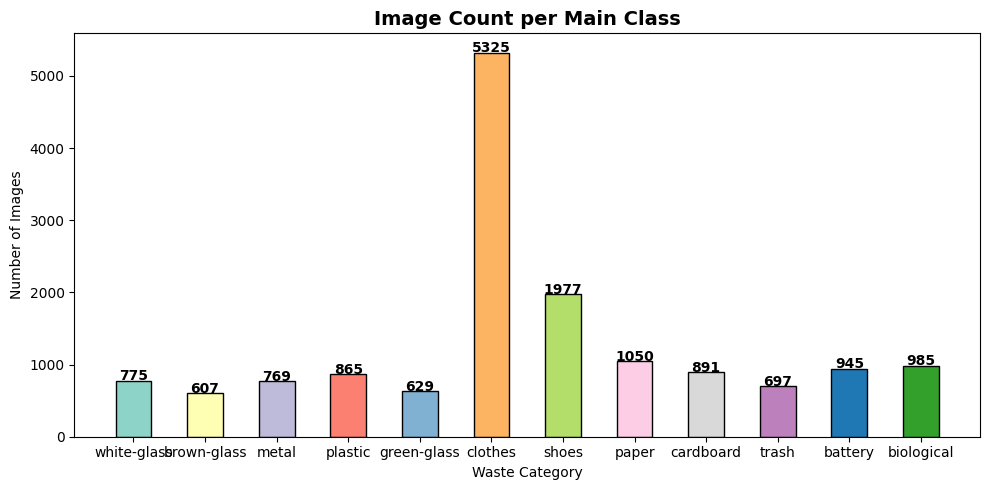

In [15]:
colors = ['#8dd3c7', '#ffffb3', '#bebada', '#fb8072', '#80b1d3', '#fdb462', '#b3de69', '#fccde5', '#d9d9d9', '#bc80bd', '#1f78b4', '#33a02c']

plt.figure(figsize=(10, 5))
bars = plt.bar(class_totals.keys(), class_totals.values(),
               color=colors[:len(class_totals)], edgecolor='black', width=0.5)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             str(bar.get_height()),
             ha='center', fontweight='bold')
plt.title('Image Count per Main Class', fontsize=14, fontweight='bold')
plt.xlabel('Waste Category')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.savefig('main_class_distribution.png', dpi=150)
plt.show()

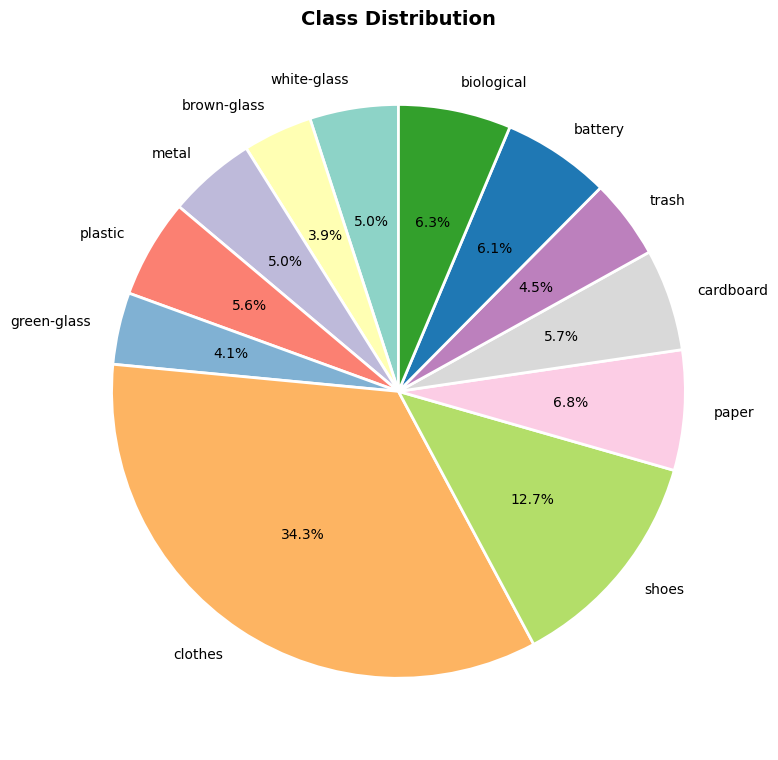

In [16]:
plt.figure(figsize=(8, 8))
plt.pie(class_totals.values(),
        labels=class_totals.keys(),
        colors=colors[:len(class_totals)],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_pie.png', dpi=150)
plt.show()

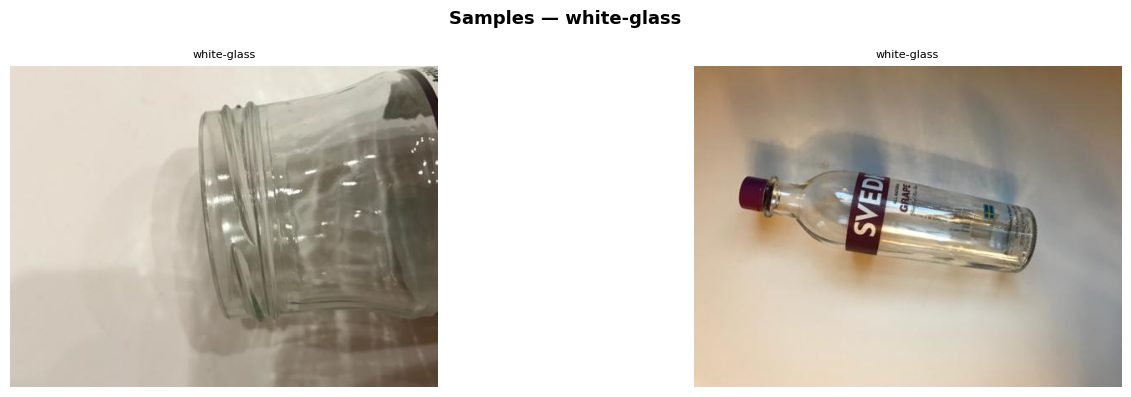

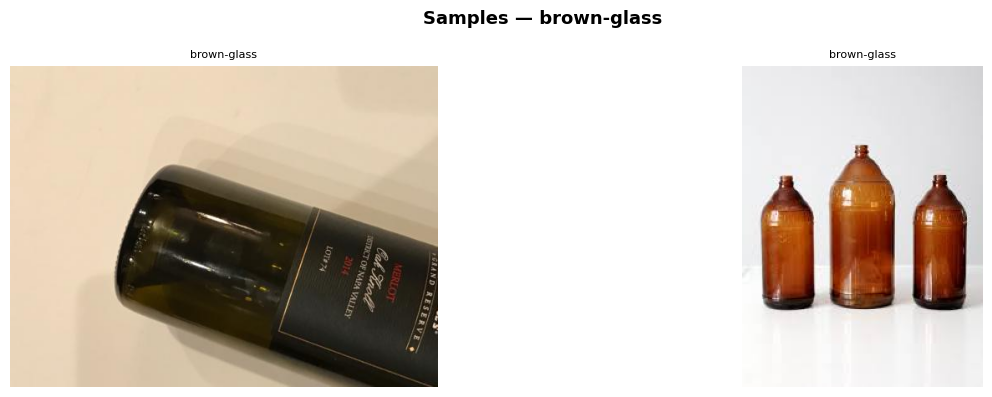

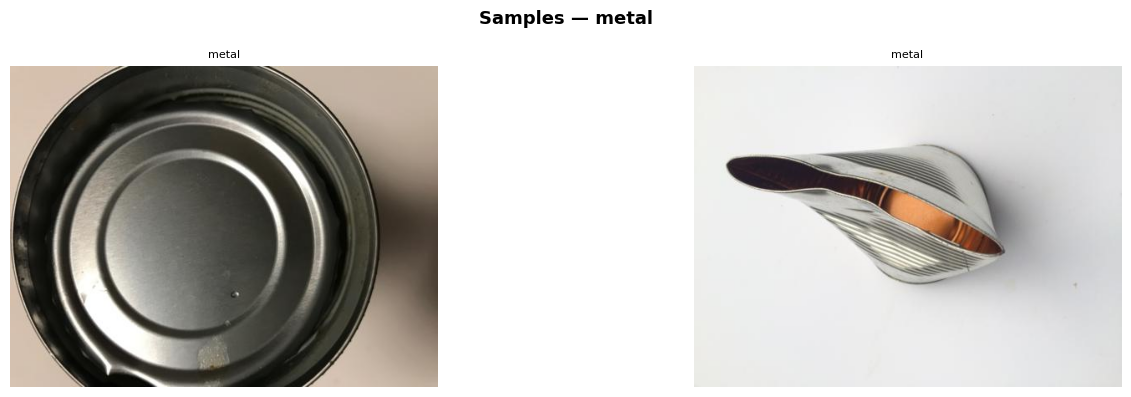

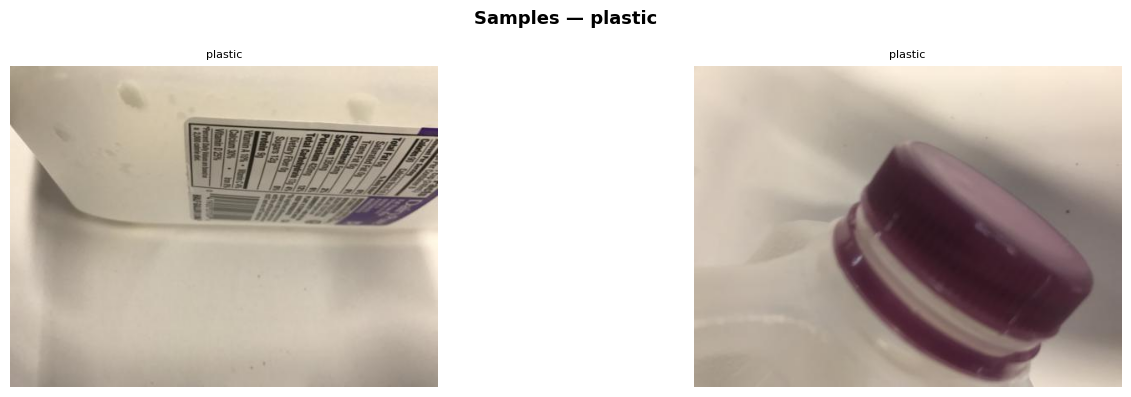

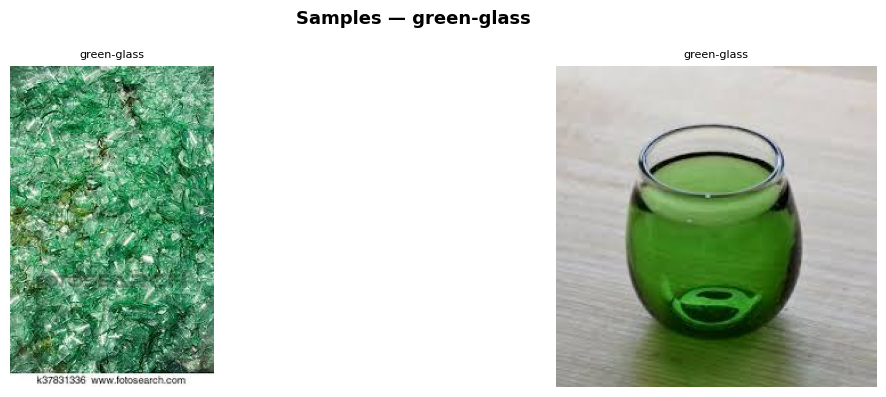

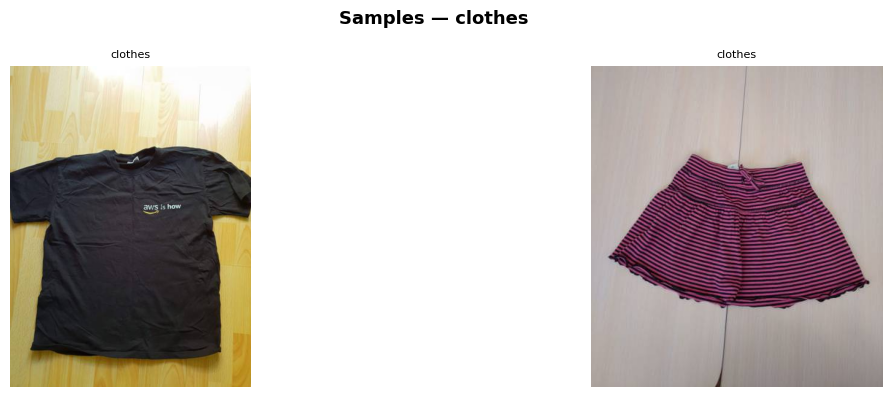

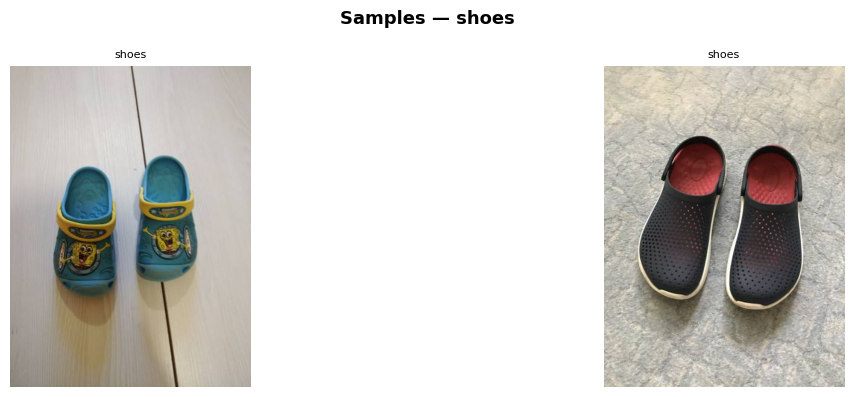

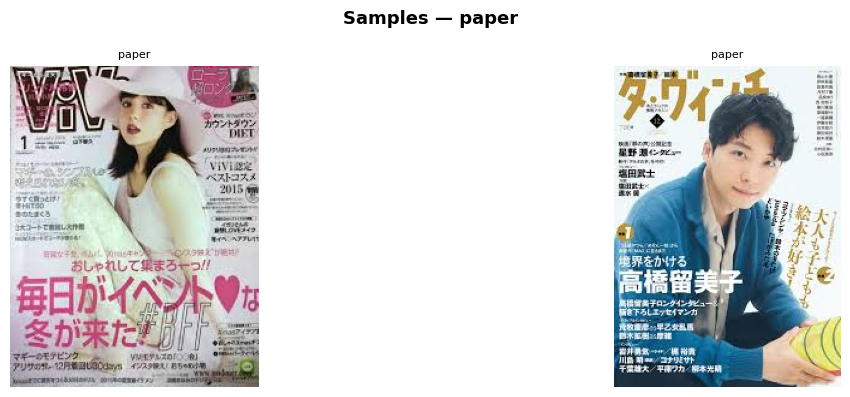

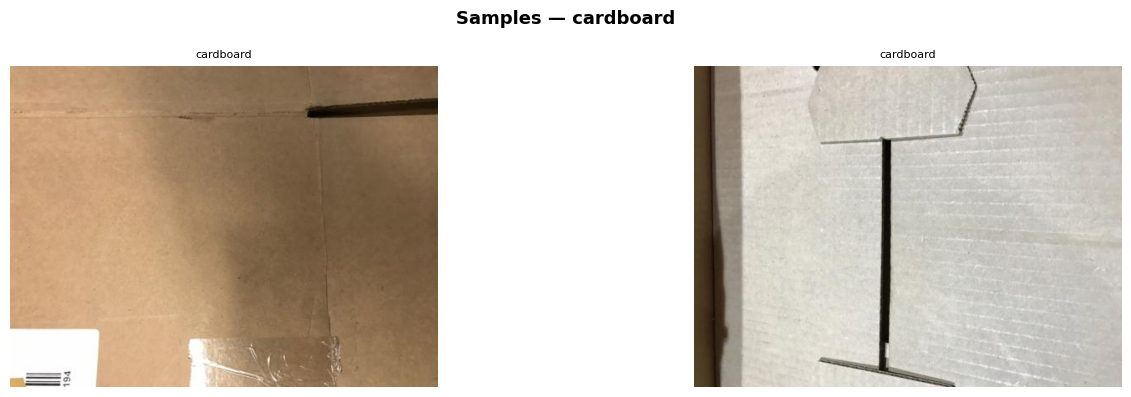

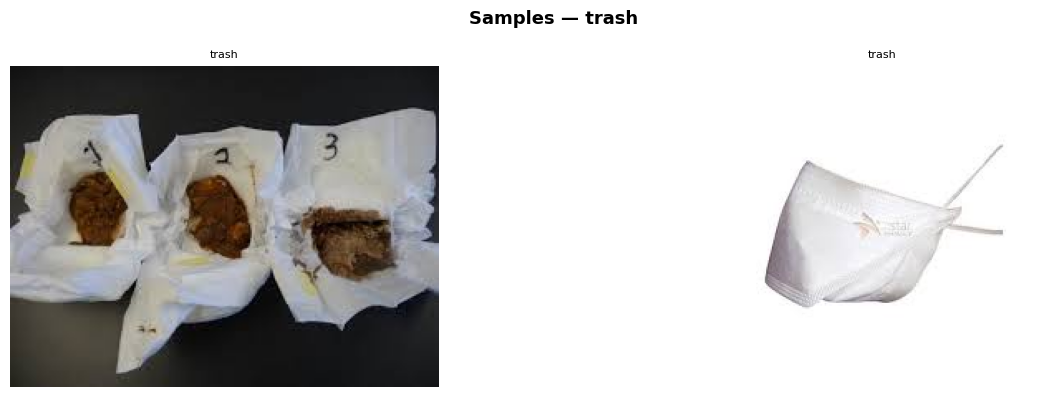

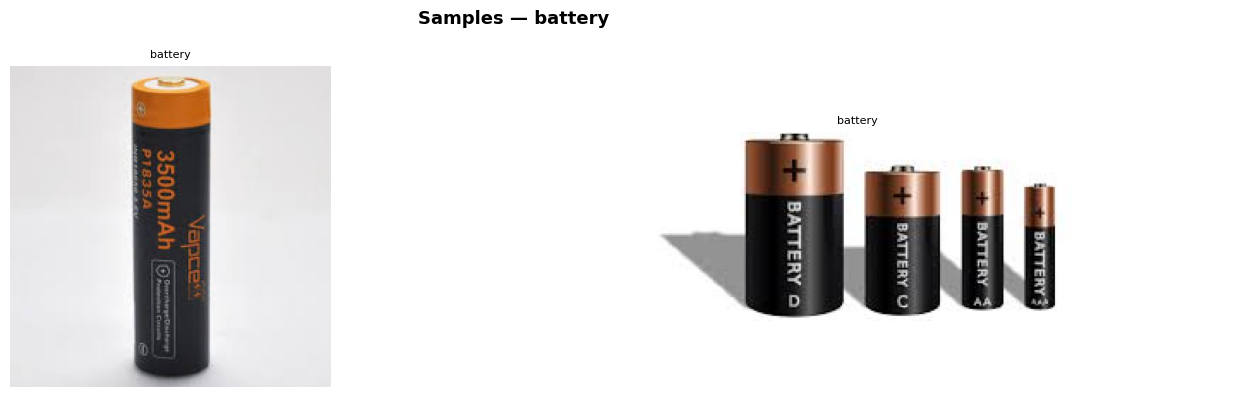

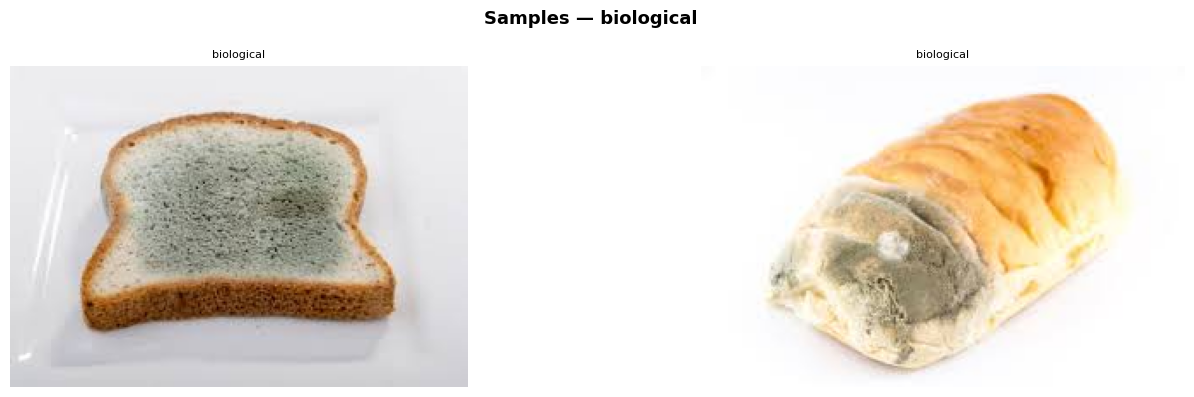

In [12]:
def show_samples(base_path, top_class, all_folders_dict, n=6):
    collected = []
    for rel_path, count in all_folders_dict.items():
        parts = rel_path.replace('\\', '/').split('/')
        if parts[0] == top_class:
            folder_full = os.path.join(base_path, rel_path)
            sub_name = parts[-1]
            for f in os.listdir(folder_full)[:2]:
                if f.lower().endswith(('.jpg','.jpeg','.png')):
                    collected.append((os.path.join(folder_full, f), sub_name))
        if len(collected) >= n:
            break

    if not collected:
        print(f"⚠️ No images found for {top_class}")
        return

    fig, axes = plt.subplots(1, min(n, len(collected)), figsize=(15, 4))
    if len(collected) == 1:
        axes = [axes]
    fig.suptitle(f'Samples — {top_class}', fontsize=13, fontweight='bold')
    for i, (img_path, label) in enumerate(collected[:n]):
        try:
            img = mpimg.imread(img_path)
            axes[i].imshow(img)
            axes[i].set_title(label, fontsize=8)
            axes[i].axis('off')
        except:
            pass

    plt.tight_layout()
    plt.savefig(f'samples_{top_class}.png', dpi=150)
    plt.show()

for cls in class_totals.keys():
    show_samples(DATASET_PATH, cls, all_folders)

In [13]:
print("\n" + "="*45)
print("       📊 DATASET SUMMARY")
print("="*45)
for k, v in class_totals.items():
    print(f"  {k:<20}: {v:>5} images")
print(f"  {'TOTAL':<20}: {sum(class_totals.values()):>5} images")
print("="*45)
print("✅ EDA Complete!")


       📊 DATASET SUMMARY
  white-glass         :   775 images
  brown-glass         :   607 images
  metal               :   769 images
  plastic             :   865 images
  green-glass         :   629 images
  clothes             :  5325 images
  shoes               :  1977 images
  paper               :  1050 images
  cardboard           :   891 images
  trash               :   697 images
  battery             :   945 images
  biological          :   985 images
  TOTAL               : 15515 images
✅ EDA Complete!
